<a href="https://colab.research.google.com/github/tanuiivy/bbt4106-202604-D4-regression/blob/feature%2Feda-ivy/bbt4106_202604_D4_d_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Annual Farm Income: A Regression Analysis of Kenyan Smallholder and Commercial Farms
### BBT4106 — Business Intelligence I | Group D4

## 1. Setup & Dependencies

In [117]:
# Install `ipykernel` for Jupyter notebook
%pip install ipykernel

In [118]:
# Setup & Dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
import urllib.request
import os


# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
sns.set_style('whitegrid')

TARGET = 'annual_farm_income_kes'

## 2. Data Loading & Exploratory Data Analysis

In [119]:
# Load the Dataset
dataset_path = './data/farm_annual_income.csv'
url = 'https://raw.githubusercontent.com/tanuiivy/bbt4106-202604-D4-regression/refs/heads/main/farm_annual_income.csv'

if not os.path.exists(dataset_path):
    print("Downloading dataset...")
    if not os.path.exists('./data'):
        os.makedirs('./data')
    urllib.request.urlretrieve(url, dataset_path)
    print("Dataset downloaded✅ ")
else:
    print("Dataset already exists locally✅ ")

farm_data = pd.read_csv(dataset_path, encoding='utf-8')
print(f"Shape: {farm_data.shape[0]} rows, {farm_data.shape[1]} columns")
farm_data.head()

Dataset already exists locally✅ 
Shape: 850 rows, 16 columns


,farm_id,crop_type,county,irrigation_type,cooperative_member,farm_size_acres,years_farming_experience,num_workers_employed,rainfall_mm,soil_quality_score,market_distance_km,machinery_value_kes,fertilizer_spend_kes,pesticide_spend_kes,irrigation_maintenance_cost_kes,annual_farm_income_kes
0,1,Tea,Uasin Gishu,Drip,No,7.26,10.0,1,1345.0,NaN,5.7,31304.0,22569.0,11598.0,20609.323557,240514.0
1,2,Tea,Nakuru,Drip,No,15.73,39.8,4,739.0,38.000299,11.3,156636.0,52716.0,13887.0,2849.905605,562457.0
2,3,Tea,Uasin Gishu,NaN,No,7.75,3.3,2,1101.0,57.136048,29.3,15966.0,28291.0,10697.0,NaN,176021.0
3,4,Coffee,Nakuru,NaN,No,3.90,30.6,1,831.0,73.593459,14.1,29920.0,16108.0,5383.0,NaN,283876.0
4,5,Tea,Kericho,Manual,No,10.49,9.3,1,967.0,54.498549,6.0,115136.0,28664.0,4486.0,3207.355224,242651.0


### 2.1 Shape, Data Types & Target Overview

In [120]:
# 2.1 Shape, Data Types & Target
farm_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   farm_id                          850 non-null    int64  
 1   crop_type                        850 non-null    object 
 2   county                           850 non-null    object 
 3   irrigation_type                  547 non-null    object 
 4   cooperative_member               850 non-null    object 
 5   farm_size_acres                  850 non-null    float64
 6   years_farming_experience         850 non-null    float64
 7   num_workers_employed             850 non-null    int64  
 8   rainfall_mm                      850 non-null    float64
 9   soil_quality_score               807 non-null    float64
 10  market_distance_km               850 non-null    float64
 11  machinery_value_kes              850 non-null    float64
 12  fertilizer_spend_kes  

In [121]:
print(f"Target variable: {TARGET}")

Target variable: annual_farm_income_kes


In [122]:
farm_data[TARGET].describe()

,annual_farm_income_kes
count,8.500000e+02
mean,2.686471e+05
std,1.608326e+05
min,5.653400e+04
25%,1.683308e+05
50%,2.237460e+05
75%,3.279118e+05
max,2.060104e+06


In [123]:
print(f"Number of features (excluding IDs and the target): {farm_data.shape[1] - 2}")

Number of features (excluding IDs and the target): 14


### 2.2 Measures of Central Tendency & Distribution

In [124]:
""" Split columns into numeric (measures) and categorical (dimensions) so we can apply the right statistics to each:
central tendency/distribution measures for numeric columns, frequency tables for categorical ones."""

numeric_cols = farm_data.select_dtypes(include=[np.number]).columns.drop('farm_id')
categorical_cols = farm_data.select_dtypes(exclude=[np.number]).columns

print("Numeric columns (measures):")
print(numeric_cols.tolist())

print("\nCategorical columns (dimensions):")
print(categorical_cols.tolist())

Numeric columns (measures):
['farm_size_acres', 'years_farming_experience', 'num_workers_employed', 'rainfall_mm', 'soil_quality_score', 'market_distance_km', 'machinery_value_kes', 'fertilizer_spend_kes', 'pesticide_spend_kes', 'irrigation_maintenance_cost_kes', 'annual_farm_income_kes']

Categorical columns (dimensions):
['crop_type', 'county', 'irrigation_type', 'cooperative_member']


In [125]:
# Summarise the frequency and percentage of each categorical variable

for col in categorical_cols:
    print(f"\n--- {col} ---")
    freq_table = farm_data[col].value_counts(dropna=False)
    pct_table = farm_data[col].value_counts(normalize=True, dropna=False) * 100
    summary = pd.DataFrame({'count': freq_table, 'percent': pct_table.round(1)})
    print(summary)


--- crop_type ---
              count  percent
crop_type                   
Maize           266     31.3
Tea             171     20.1
Horticulture    171     20.1
Dairy           138     16.2
Coffee          104     12.2

--- county ---
             count  percent
county                     
Other          180     21.2
Nakuru         168     19.8
Kiambu         137     16.1
Kericho        128     15.1
Meru           121     14.2
Uasin Gishu    116     13.6

--- irrigation_type ---
                 count  percent
irrigation_type                
NaN                303     35.6
Manual             225     26.5
Drip               198     23.3
Automated          124     14.6

--- cooperative_member ---
                    count  percent
cooperative_member                
Yes                   483     56.8
No                    367     43.2


In [126]:
# Calculate descriptive statistics and distribution measures for numeric variables

q1 = farm_data[numeric_cols].quantile(0.25)
q2 = farm_data[numeric_cols].quantile(0.50)
q3 = farm_data[numeric_cols].quantile(0.75)
iqr = q3 - q1

distribution_summary = pd.DataFrame({
    "min": farm_data[numeric_cols].min(),
    "q1_25%": q1,
    "q2_50%_median": q2,
    "q3_75%": q3,
    "max": farm_data[numeric_cols].max(),
    "mean": farm_data[numeric_cols].mean(),
    "mode": farm_data[numeric_cols].mode().iloc[0],
    "variance": farm_data[numeric_cols].var(),
    "std_dev": farm_data[numeric_cols].std(),
    "skewness": farm_data[numeric_cols].skew(),
    "kurtosis": farm_data[numeric_cols].kurt(),
    "IQR": iqr,
    "lower_fence": q1 - 1.5 * iqr,
    "upper_fence": q3 + 1.5 * iqr,
})

distribution_summary.round(2)

,min,q1_25%,q2_50%_median,q3_75%,max,mean,mode,variance,std_dev,skewness,kurtosis,IQR,lower_fence,upper_fence
farm_size_acres,0.5,3.90,6.34,10.09,31.44,7.68,3.04,2.651000e+01,5.15,1.19,1.40,6.19,-5.38,19.38
years_farming_experience,0.5,6.72,11.40,17.70,45.00,13.37,6.20,7.850000e+01,8.86,1.25,1.56,10.98,-9.74,34.16
num_workers_employed,0.0,1.00,2.00,3.00,9.00,2.03,1.00,2.830000e+00,1.68,0.76,0.26,2.00,-2.00,6.00
rainfall_mm,250.0,800.00,951.00,1091.75,1566.00,946.02,951.00,4.775720e+04,218.53,0.02,-0.08,291.75,362.38,1529.38
soil_quality_score,5.0,49.73,61.61,73.89,100.00,61.63,100.00,2.950900e+02,17.18,-0.16,-0.12,24.16,13.50,110.13
market_distance_km,1.0,8.10,13.65,22.20,68.50,16.39,1.00,1.322700e+02,11.50,1.27,1.81,14.10,-13.05,43.35
machinery_value_kes,0.0,29763.50,56409.50,95019.00,350170.00,69103.23,0.00,3.042008e+09,55154.40,1.31,1.92,65255.50,-68119.75,192902.25
fertilizer_spend_kes,1104.0,11143.00,19577.00,33529.00,133274.00,24391.90,10424.00,3.312240e+08,18199.56,1.58,3.73,22386.00,-22436.00,67108.00
pesticide_spend_kes,199.0,4718.25,8587.50,13805.25,50169.00,10560.84,1540.00,6.843423e+07,8272.50,1.63,3.43,9087.00,-8912.25,27435.75
irrigation_maintenance_cost_kes,500.0,4057.64,7532.92,12234.66,36866.42,8994.86,500.00,4.036150e+07,6353.07,1.30,2.00,8177.02,-8207.89,24500.19


In [127]:
print(f"""
The target variable, annual_farm_income_kes, shows the most extreme distribution shape in the dataset:
skewness of {distribution_summary.loc['annual_farm_income_kes', 'skewness']:.2f} and kurtosis of {distribution_summary.loc['annual_farm_income_kes', 'kurtosis']:.2f}.
A skewness this high (well above the common >1 threshold for 'highly skewed') confirms a strong right skew:
most farms earn moderate income, but a small number of very high-income farms pull the mean (KES 268,647) well above the median (KES 223,746).
The kurtosis of 23.58 is exceptionally high compared to every other numeric column in the dataset.
This signals heavy tails, meaning extreme outlier farms exist far beyond what a normal distribution would predict.
This will require a variance-stabilizing transform (log1p, Box-Cox, or Yeo-Johnson) during preprocessing,
and diagnostic checks like Cook's distance will likely flag these same high-income farms as influential points.
""")


The target variable, annual_farm_income_kes, shows the most extreme distribution shape in the dataset: 
skewness of 3.38 and kurtosis of 23.58. 
A skewness this high (well above the common >1 threshold for 'highly skewed') confirms a strong right skew:
most farms earn moderate income, but a small number of very high-income farms pull the mean (KES 268,647) well above the median (KES 223,746). 
The kurtosis of 23.58 is exceptionally high compared to every other numeric column in the dataset.
This signals heavy tails, meaning extreme outlier farms exist far beyond what a normal distribution would predict. 
This will require a variance-stabilizing transform (log1p, Box-Cox, or Yeo-Johnson) during preprocessing, 
and diagnostic checks like Cook's distance will likely flag these same high-income farms as influential points.



In [128]:
print("""
These distribution shapes carry directly into later stages:
the target's extreme skew and kurtosis mean a transformation is very likely necessary before modeling (Section 5.3),
and the same high-income farms that inflate skew here are the ones most likely to surface as high-leverage points in diagnostics (Section 7) and outliers worth investigating rather than automatically deleting.
""")


These distribution shapes carry directly into later stages: 
the target's extreme skew and kurtosis mean a transformation is very likely necessary before modeling (Section 5.3),
and the same high-income farms that inflate skew here are the ones most likely to surface as high-leverage points in diagnostics (Section 7) and outliers worth investigating rather than automatically deleting.



### 2.3 Skewness, Kurtosis & Outlier Detection (IQR/Boxplot)

In [129]:
""" Identify values below the lower fence or above the upper fence for each numeric column.
Per 2.2, lower fences are meaningless for the KES columns (negative), so in practice this mainly catches upper-tail outliers."""

outlier_mask = (
    (farm_data[numeric_cols] < (q1 - 1.5 * iqr)) |
    (farm_data[numeric_cols] > (q3 + 1.5 * iqr))
)

outlier_counts = outlier_mask.sum().rename("outlier_count").to_frame()
outlier_counts

,outlier_count
farm_size_acres,35
years_farming_experience,31
num_workers_employed,10
rainfall_mm,5
soil_quality_score,5
market_distance_km,30
machinery_value_kes,34
fertilizer_spend_kes,28
pesticide_spend_kes,37
irrigation_maintenance_cost_kes,16


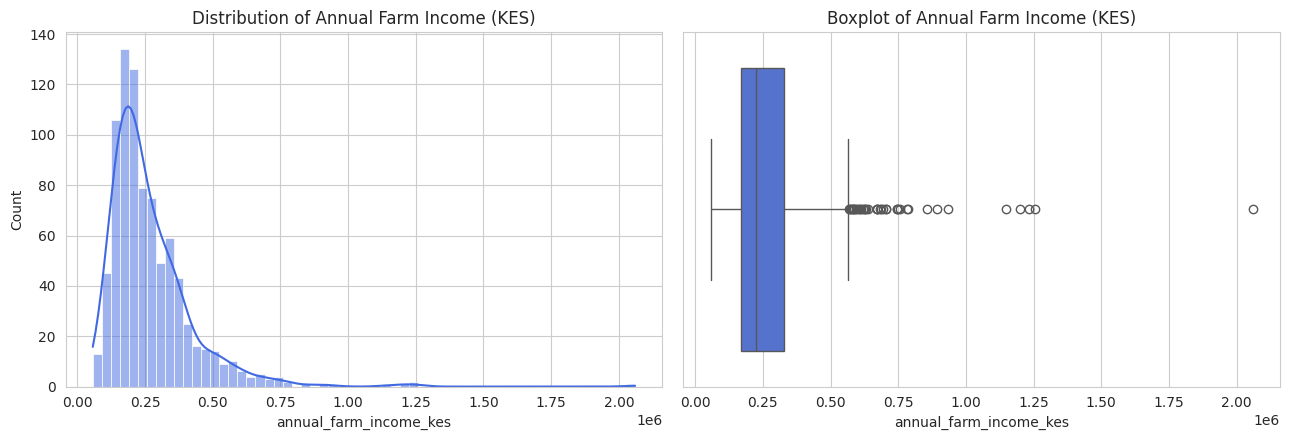

In [142]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Histogram: "Count" shows the number of farms in each income range.
# The x-axis uses scientific notation because income values are large.
# For example, "1e6" means 1,000,000 (KES 1 million).

sns.histplot(farm_data[TARGET], kde=True, ax=axes[0], color="#4169E1")
axes[0].set_title("Distribution of Annual Farm Income (KES)")

# Boxplot: box = middle 50% of farms, line = median, dots = outliersbeyond the 1.5×IQR fences from 2.2/2.3.
sns.boxplot(x=farm_data[TARGET], ax=axes[1], color="#4169E1")
axes[1].set_title("Boxplot of Annual Farm Income (KES)")

plt.tight_layout()
plt.show()

In [131]:
n_income_outliers = outlier_counts.loc[TARGET, 'outlier_count']
print(f"""
The histogram confirms the right skew already seen numerically:
a dense cluster of farms in the KES 150,000-350,000 range, with a long thin tail stretching toward KES 2,000,000.
The boxplot shows {n_income_outliers} farms flagged as statistical outliers using the 1.5×IQR rule.
These are the same high-income commercial farms driving the skewness of 3.38 and kurtosis of 23.58 computed in 2.2.
Rather than deleting these rows outright, they warrant individual inspection later, since they may represent genuine large commercial operations rather than data-entry errors.
""")


The histogram confirms the right skew already seen numerically: 
a dense cluster of farms in the KES 150,000-350,000 range, with a long thin tail stretching toward KES 2,000,000. 
The boxplot shows 39 farms flagged as statistical outliers using the 1.5×IQR rule. 
These are the same high-income commercial farms driving the skewness of 3.38 and kurtosis of 23.58 computed in 2.2.
Rather than deleting these rows outright, they warrant individual inspection later, since they may represent genuine large commercial operations rather than data-entry errors.



### 2.4 Correlation & Relationship Analysis

In [132]:
# Pearson correlation captures linear relationships; Spearman captures monotonic, possibly non-linear relationships.
# Comparing the two flags predictors where the relationship isn't a straight line.

pearson_corr = farm_data[numeric_cols].corr(method="pearson")[TARGET].drop(TARGET).sort_values(ascending=False)
spearman_corr = farm_data[numeric_cols].corr(method="spearman")[TARGET].drop(TARGET).sort_values(ascending=False)

relationship_summary = pd.DataFrame({"Pearson": pearson_corr, "Spearman": spearman_corr})
relationship_summary["gap"] = (relationship_summary["Spearman"] - relationship_summary["Pearson"]).abs()
relationship_summary.sort_values("gap", ascending=False).round(3)

,Pearson,Spearman,gap
rainfall_mm,0.057,0.118,0.062
soil_quality_score,0.128,0.160,0.031
irrigation_maintenance_cost_kes,0.026,0.055,0.029
years_farming_experience,0.528,0.512,0.016
machinery_value_kes,0.003,-0.010,0.013
farm_size_acres,0.010,-0.002,0.012
pesticide_spend_kes,-0.010,-0.002,0.009
fertilizer_spend_kes,0.008,0.001,0.007
market_distance_km,-0.071,-0.070,0.001
num_workers_employed,0.048,0.047,0.001


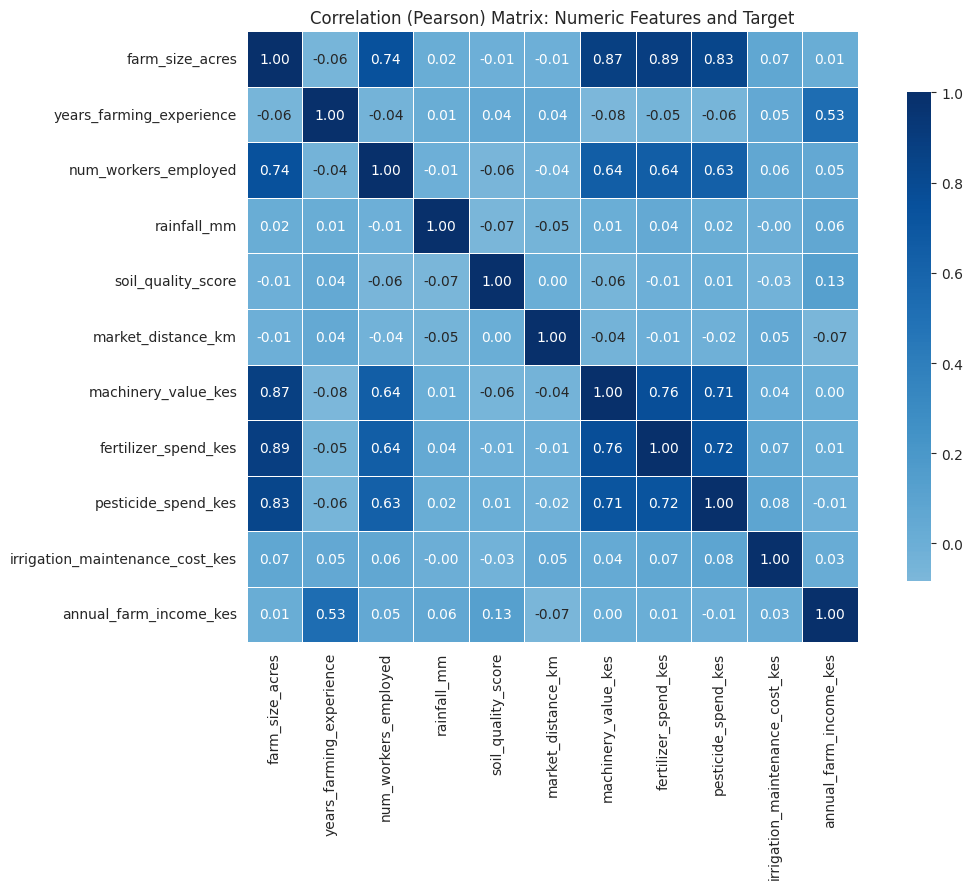

In [133]:
plt.figure(figsize=(12, 9))

corr_matrix = farm_data[numeric_cols].corr(method="pearson")
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="Blues", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.title("Correlation (Pearson) Matrix: Numeric Features and Target")
plt.tight_layout()
plt.show()

In [134]:
print(f"""
years_farming_experience shows by far the strongest relationship with annual_farm_income_kes
(Pearson {relationship_summary.loc['years_farming_experience','Pearson']:.2f}, Spearman {relationship_summary.loc['years_farming_experience','Spearman']:.2f}) — a moderate positive correlation. Every other numeric feature, including farm_size_acres (0.01),
machinery_value_kes (0.00), fertilizer_spend_kes (0.01), and pesticide_spend_kes (-0.01),
shows essentially no linear or monotonic relationship with income at all.
This is a genuinely counter-intuitive finding: farm scale and input spending do not, on their own, predict how much a farm earns, experience does.
This suggests income may depend more on farming skill/practice than on physical scale, or that the relationship between spending and income is more complex than a simple linear or monotonic one
(e.g. it may only pay off in combination with experience).
""")


years_farming_experience shows by far the strongest relationship with annual_farm_income_kes 
(Pearson 0.53, Spearman 0.51) — a moderate positive correlation. Every other numeric feature, including farm_size_acres (0.01), 
machinery_value_kes (0.00), fertilizer_spend_kes (0.01), and pesticide_spend_kes (-0.01), 
shows essentially no linear or monotonic relationship with income at all. 
This is a genuinely counter-intuitive finding: farm scale and input spending do not, on their own, predict how much a farm earns, experience does.
This suggests income may depend more on farming skill/practice than on physical scale, or that the relationship between spending and income is more complex than a simple linear or monotonic one 
(e.g. it may only pay off in combination with experience).



In [135]:
print("""
The heatmap reveals a clear multicollinearity cluster: farm_size_acres correlates strongly with machinery_value_kes (0.87), fertilizer_spend_kes (0.89), pesticide_spend_kes (0.83), and num_workers_employed (0.74).
These four inputs also correlate moderately with each other (0.63-0.76).
This makes practical sense as larger farms naturally need more machinery, more workers, and more fertilizer/pesticide simply due to scale, not because each input independently drives outcomes.
This cluster is flagged here for Section 2 (Feature Selection): VIF analysis will very likely need to drop or combine several of these five correlated columns to avoid redundant, unstable coefficients in the regression model.
""")


The heatmap reveals a clear multicollinearity cluster: farm_size_acres correlates strongly with machinery_value_kes (0.87), fertilizer_spend_kes (0.89), pesticide_spend_kes (0.83), and num_workers_employed (0.74).
These four inputs also correlate moderately with each other (0.63-0.76). 
This makes practical sense as larger farms naturally need more machinery, more workers, and more fertilizer/pesticide simply due to scale, not because each input independently drives outcomes. 
This cluster is flagged here for Section 2 (Feature Selection): VIF analysis will very likely need to drop or combine several of these five correlated columns to avoid redundant, unstable coefficients in the regression model.



In [136]:
print("""
As with any correlation analysis, these relationships describe association, not causation.
A positive correlation between years_farming_experience and income does not prove that experience alone causes higher earnings;
unmeasured factors (e.g. crop choice, county-level market access) could influence both.""")


As with any correlation analysis, these relationships describe association, not causation. 
A positive correlation between years_farming_experience and income does not prove that experience alone causes higher earnings; 
unmeasured factors (e.g. crop choice, county-level market access) could influence both.


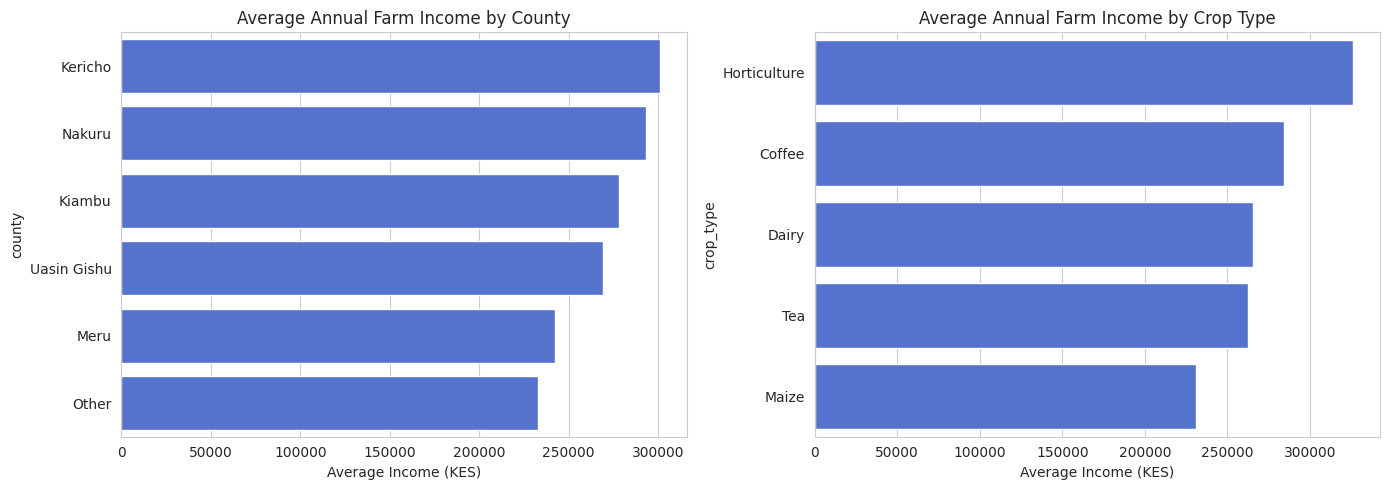

In [141]:
# Combine a dimension (categorical) with the target (measure).
# Showing a side by side for county and crop_type since both are business-relevant groupings for farm income specifically.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

county_avg = farm_data.groupby('county')[TARGET].mean().sort_values(ascending=False)
sns.barplot(x=county_avg.values, y=county_avg.index, ax=axes[0], color="#4169E1")
axes[0].set_title("Average Annual Farm Income by County")
axes[0].set_xlabel("Average Income (KES)")

crop_avg = farm_data.groupby('crop_type')[TARGET].mean().sort_values(ascending=False)
sns.barplot(x=crop_avg.values, y=crop_avg.index, ax=axes[1], color="#4169E1")
axes[1].set_title("Average Annual Farm Income by Crop Type")
axes[1].set_xlabel("Average Income (KES)")

plt.tight_layout()
plt.show()

In [138]:
print(f"""
County averages range from roughly KES {county_avg.min():,.0f} ({county_avg.idxmin()}) to KES {county_avg.max():,.0f} ({county_avg.idxmax()}),
while crop-type averages range from KES {crop_avg.min():,.0f} ({crop_avg.idxmin()}) to KES {crop_avg.max():,.0f} ({crop_avg.idxmax()}).
Horticulture farms earn the most on average, roughly 40% more than Maize farms, and Kericho county farms outearn the "Other" county grouping by a similar margin.
These gaps are real but still smaller than the spread driven by years_farming_experience (Pearson 0.53), suggesting crop choice and location matter,
but farmer experience remains the dominant single factor in this dataset.
""")


County averages range from roughly KES 232,736 (Other) to KES 301,020 (Kericho), 
while crop-type averages range from KES 230,882 (Maize) to KES 326,191 (Horticulture). 
Horticulture farms earn the most on average, roughly 40% more than Maize farms, and Kericho county farms outearn the "Other" county grouping by a similar margin. 
These gaps are real but still smaller than the spread driven by years_farming_experience (Pearson 0.53), suggesting crop choice and location matter, 
but farmer experience remains the dominant single factor in this dataset.



## 3. Train/Test Split

####The Split ####

In [139]:
# Create a temporary binned target purely for stratification purposes.
# Given annual_farm_income_kes's strong right skew (skewness 3.38), a plain random split risks placing a disproportionate share of high-income farms into either train or test.
# Quantile binning ensures both sets contain a comparable mix of low-, medium-, and high-income farms.

income_bins = pd.qcut(farm_data[TARGET], q=5, labels=False, duplicates="drop")

X = farm_data.drop(columns=['farm_id', TARGET])
y = farm_data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=income_bins
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

Training set: 680 rows
Test set: 170 rows


In [140]:
print(f"""
An 80/20 split was chosen given the dataset's moderate size (850 rows),
allocating {X_train.shape[0]} farms for training and {X_test.shape[0]} for testing.
Because the target is heavily right-skewed, the split was stratified on quantile-based income bins
(5 bins via pd.qcut) rather than performed as a plain random split ensuring both sets contain a comparable mix of low-, medium-, and high-income farms.
""")


An 80/20 split was chosen given the dataset's moderate size (850 rows), 
allocating 680 farms for training and 170 for testing. 
Because the target is heavily right-skewed, the split was stratified on quantile-based income bins 
(5 bins via pd.qcut) rather than performed as a plain random split ensuring both sets contain a comparable mix of low-, medium-, and high-income farms.



**Hypothesis Formulation**

Based on the patterns observed in the EDA above, we formulate the following hypothesis for the modeling stage:

H1: years_farming_experience is the strongest predictor of annual_farm_income_kes among the numeric features examined, given its moderate positive correlation (Pearson 0.53) compared to near-zero "correlations for farm_size_acres, machinery_value_kes, and the input spending variables. This suggests income is driven more by farming practice/skill accumulated over time than by physical scale or capital investment alone.

H2: The farm_size_acres cluster (farm_size_acres, machinery_value_kes,fertilizer_spend_kes, pesticide_spend_kes, num_workers_employed) exhibits multicollinearity and will require dimensionality reduction or feature
selection before modeling to avoid unstable coefficient estimates.

## 4. Feature Selection

### 4.1 Correlation Filtering

### 4.2 Variance Inflation Factor (VIF)

### 4.3 Selected Features & Rationale

## 5. Preprocessing Pipeline

### 5.1 Handling Missingness (Structural vs. Random)

### 5.2 Encoding & Scaling

### 5.3 Target Transformation

## 6. Modeling & Cross-Validation

### 6.1 Candidate Models

### 6.2 K-Fold Cross-Validation Results

## 7. Diagnostics

### 7.1 Linearity

### 7.2 Autocorrelation

### 7.3 Normality of Errors

### 7.4 Homoscedasticity

## 8. Evaluation of Candidate Models

### 8.1 Test-Set Performance Comparison

### 8.2 Final Model Selection & Justification

## 9. Hyperparameter Tuning

### 9.1 Grid/Randomized Search

### 9.2 Tuned vs. Untuned Comparison


## 10. Explainability

### 10.1 Feature Importance / Coefficients

### 10.2 SHAP Analysis

## 11. Model Persistence

### 11.1 Saving the Pipeline

### 11.2 Reload & Manual Prediction Demo

## 12. Conclusion & Limitations